# Torneo de Modelos - Sklearn

Entrenamiento y comparación de Random Forest y LightGBM con particiones train/test/val desde config.yaml

## 1. Importaciones

In [1]:
import pandas as pd
import numpy as np
import yaml
import warnings
import pickle
import json
from datetime import datetime
from pathlib import Path

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
)
import lightgbm as lgb

warnings.filterwarnings('ignore')
print("✅ Importaciones completadas")

✅ Importaciones completadas


## 2. Configuración

In [2]:
# Rutas
base_path = Path.cwd()
config_path = base_path / 'config' / 'config.yaml'
data_path = base_path / 'data' / 'base_final.csv'

print(f"📁 Base: {base_path}")
print(f"📁 Datos: {data_path}")

# Cargar YAML
with open(config_path, 'r', encoding='utf-8') as f:
    config = yaml.safe_load(f)

print(f"\n✅ Proyecto: {config['project_name']['name']} v{config['project_name']['version']}")

📁 Base: c:\Users\seaherre\Documents\Repositorios\prueba-tecnica\src\torneo_modelos
📁 Datos: c:\Users\seaherre\Documents\Repositorios\prueba-tecnica\src\torneo_modelos\data\base_final.csv

✅ Proyecto: Prueba técnica v0.1.0


## 3. Cargar y Explorar Datos

In [3]:
df = pd.read_csv(data_path)

print(f"📊 Datos cargados: {df.shape}")
print(f"\n🔍 Exploración de la columna de partición 'uso_detalle':")
print(df['uso_detalle'].value_counts().sort_index())

📊 Datos cargados: (680800, 40)

🔍 Exploración de la columna de partición 'uso_detalle':
uso_detalle
excluido_test     60276
test              40190
train            467785
val              112549
Name: count, dtype: int64


## 4. Extraer Configuración y Seleccionar Features

In [4]:
# Extraer del config
target_col = config['global']['target']
features_cfg = config['global']['features']
to_keep_cat = features_cfg['to_keep']['categorical']
to_keep_num = features_cfg['to_keep']['numerical']
particion_col = config['training_steps']['particionar_base']['columna']['nombre_columna']
seed = config['global']['seed']

print(f"📋 Configuración extraída:")
print(f"  Target: {target_col}")
print(f"  Partición: {particion_col}")
print(f"  Features categóricas: {len(to_keep_cat)}")
print(f"  Features numéricas: {len(to_keep_num)}")
print(f"  Seed: {seed}")

# Seleccionar features (incluir partición para luego)
features_to_use = to_keep_cat + to_keep_num + [particion_col]
X = df[features_to_use].copy()
y = df[target_col].copy()

print(f"\n📊 Features seleccionadas: {X.shape}")
print(f"  Categóricas: {to_keep_cat}")
print(f"  Numéricas: {to_keep_num}")

📋 Configuración extraída:
  Target: var_rpta_alt
  Partición: uso_detalle
  Features categóricas: 13
  Features numéricas: 13
  Seed: 2024

📊 Features seleccionadas: (680800, 27)
  Categóricas: ['genero_cli', 'estado_civil', 'ocup', 'origen_fondos', 'canal_actualizacion', 'cli_actualizado', 'segm', 'subsegm', 'region_of', 'nombre_dpto_dirp', 'producto_pagos', 'aplicativo_pagos', 'marca_pago_pagos']
  Numéricas: ['prob_propension', 'prob_alrt_temprana', 'prob_auto_cura', 'ano_nac_cli', 'edad_cli', 'total_ing', 'tot_activos', 'tot_pasivos', 'egresos_mes', 'tot_patrimonio', 'valor_cuota_mes_pagos', 'pago_total', 'porc_pago']


## 5. Codificar Variables Categóricas

In [5]:
print("📋 Codificando variables categóricas EN LA BASE COMPLETA")
print(f"  Antes: {X.shape}, dtypes {len(X.dtypes)} columnas")

label_encoders = {}

for col in to_keep_cat:
    le = LabelEncoder()
    # Fit en TODA LA BASE (combinado) para aprender todas las clases
    le.fit(X[col].astype(str))
    # Transformar
    X[col] = le.transform(X[col].astype(str))
    label_encoders[col] = le
    print(f"  ✓ {col}: {len(le.classes_)} clases")

print(f"\n✅ {len(label_encoders)} variables categóricas codificadas EN LA BASE COMPLETA")

📋 Codificando variables categóricas EN LA BASE COMPLETA
  Antes: (680800, 27), dtypes 27 columnas
  ✓ genero_cli: 3 clases
  ✓ estado_civil: 8 clases
  ✓ ocup: 15 clases
  ✓ origen_fondos: 11 clases
  ✓ canal_actualizacion: 13 clases
  ✓ cli_actualizado: 3 clases
  ✓ segm: 8 clases
  ✓ subsegm: 17 clases
  ✓ region_of: 9 clases
  ✓ nombre_dpto_dirp: 42 clases
  ✓ producto_pagos: 17 clases
  ✓ aplicativo_pagos: 8 clases
  ✓ marca_pago_pagos: 8 clases

✅ 13 variables categóricas codificadas EN LA BASE COMPLETA


## 6. Particionar Datos (Train/Test/Val)

In [6]:
print(f"📋 Particionando datos usando '{particion_col}'")
print(f"\n  Valores en la columna:")
print(X[particion_col].value_counts().sort_index())

# Crear máscaras de partición
# 'train' = entrenamiento
# 'test' = validación
# 'val' = OOT (Out-of-Time)
# 'excluido_test' = datos adicionales para entrenar modelo ganador
train_idx = X[particion_col] == 'train'
test_idx = X[particion_col] == 'test'
val_idx = X[particion_col] == 'val'
excluido_test_idx = X[particion_col] == 'excluido_test'

print(f"\n✅ Máscaras creadas:")
print(f"  TRAIN ('train'):                 {train_idx.sum()} filas")
print(f"  TEST ('test'):                   {test_idx.sum()} filas")
print(f"  VAL ('val'):                     {val_idx.sum()} filas")
print(f"  EXCLUIDO_TEST ('excluido_test'): {excluido_test_idx.sum()} filas")

# Separar sin la columna de partición (ya está codificada)
features_model = [c for c in X.columns if c != particion_col]

X_train = X[train_idx][features_model].copy()
y_train = y[train_idx].copy()

X_test = X[test_idx][features_model].copy()
y_test = y[test_idx].copy()

X_val = X[val_idx][features_model].copy()
y_val = y[val_idx].copy()

X_excluido_test = X[excluido_test_idx][features_model].copy()
y_excluido_test = y[excluido_test_idx].copy()

print(f"\n✅ Conjuntos separados (CODIFICADOS):")
print(f"  X_train:          {X_train.shape}")
print(f"  X_test:           {X_test.shape}")
print(f"  X_val:            {X_val.shape}")
print(f"  X_excluido_test:  {X_excluido_test.shape}")
print(f"  {'─'*40}")
print(f"  Total de datos:   {X_train.shape[0] + X_test.shape[0] + X_val.shape[0] + X_excluido_test.shape[0]:,} muestras")


📋 Particionando datos usando 'uso_detalle'

  Valores en la columna:
uso_detalle
excluido_test     60276
test              40190
train            467785
val              112549
Name: count, dtype: int64

✅ Máscaras creadas:
  TRAIN ('train'):                 467785 filas
  TEST ('test'):                   40190 filas
  VAL ('val'):                     112549 filas
  EXCLUIDO_TEST ('excluido_test'): 60276 filas

✅ Conjuntos separados (CODIFICADOS):
  X_train:          (467785, 26)
  X_test:           (40190, 26)
  X_val:            (112549, 26)
  X_excluido_test:  (60276, 26)
  ────────────────────────────────────────
  Total de datos:   680,800 muestras


## 5.5 Seleccionar Variables Importantes (Ensamble Débil + Ruido)

In [7]:
print("📋 Seleccionando variables importantes usando modelo débil (Random Forest)")

# Extraer configuración de selección de variables
seleccionar_vars_cfg = config['training_steps'].get('seleccionar_variables', {})
modo_seleccion = seleccionar_vars_cfg.get('modo_seleccion', 'union')
ensamble_cfg = seleccionar_vars_cfg.get('metodos', {}).get('ensamble_debil_umbral', {})

tipo_modelo_debil = ensamble_cfg.get('tipo_modelo', 'rf')
params_modelo_debil = ensamble_cfg.get('parametros_modelo', {})
k_features = ensamble_cfg.get('k_features', None)  # None = usar todas las variables

print(f"  Modo: {modo_seleccion}")
print(f"  Modelo débil: {tipo_modelo_debil}")
print(f"  Parámetros: {params_modelo_debil}")
print(f"  K features (top N): {k_features if k_features else 'No parametrizado - usar todas'}")

# Entrenar modelo débil EN TRAIN SOLAMENTE (evitar leakage)
print(f"\n🔄 Entrenando modelo débil en TRAIN ({len(X_train):,} muestras)...")

num_trees = params_modelo_debil.get('numTrees', 40)
max_depth = params_modelo_debil.get('maxDepth', 6)

modelo_debil = RandomForestClassifier(
    n_estimators=num_trees,
    max_depth=max_depth,
    random_state=seed,
    n_jobs=-1,
    verbose=0
)
modelo_debil.fit(X_train, y_train)
print(f"  ✓ Modelo débil entrenado")

# Obtener importancia de features reales
importancia_real = modelo_debil.feature_importances_
df_importancia_real = pd.DataFrame({
    'feature': X_train.columns,
    'importancia_real': importancia_real
})

# Generar variables aleatorias (RUIDO) con las mismas dimensiones
print(f"\n🎲 Generando variables aleatorias para comparación...")
np.random.seed(seed)

# Generar ruido: distribución normal y uniforme
n_samples, n_features = X_train.shape
ruido_normal = np.random.normal(0, 1, (n_samples, n_features))
ruido_uniforme = np.random.uniform(0, 1, (n_samples, n_features))

# Entrenar modelos débiles con ruido
print(f"  - Ruido Normal: {ruido_normal.shape}")
print(f"  - Ruido Uniforme: {ruido_uniforme.shape}")

modelo_ruido_normal = RandomForestClassifier(
    n_estimators=num_trees,
    max_depth=max_depth,
    random_state=seed,
    n_jobs=-1,
    verbose=0
)
modelo_ruido_normal.fit(ruido_normal, y_train)
importancia_ruido_normal = modelo_ruido_normal.feature_importances_

modelo_ruido_uniforme = RandomForestClassifier(
    n_estimators=num_trees,
    max_depth=max_depth,
    random_state=seed,
    n_jobs=-1,
    verbose=0
)
modelo_ruido_uniforme.fit(ruido_uniforme, y_train)
importancia_ruido_uniforme = modelo_ruido_uniforme.feature_importances_

print(f"  ✓ Modelos de ruido entrenados")

# Crear DataFrame de comparación
df_comparacion = pd.DataFrame({
    'feature': X_train.columns,
    'importancia_real': importancia_real,
    'ruido_normal_max': np.max(importancia_ruido_normal),
    'ruido_uniforme_max': np.max(importancia_ruido_uniforme),
    'ruido_promedio': (np.mean(importancia_ruido_normal) + np.mean(importancia_ruido_uniforme)) / 2
}).sort_values('importancia_real', ascending=False)

# Determinar features a seleccionar
if k_features and k_features > 0:
    # Usar Top-K si se parametrizó
    features_seleccionados = df_comparacion.head(k_features)['feature'].tolist()
    print(f"\n📊 Análisis de Importancia (Top-{k_features}):")
    print(f"  Features originales: {len(X_train.columns)}")
    print(f"  Features seleccionados (Top-{k_features}): {len(features_seleccionados)}")
    print(f"  Reducción: {(1 - len(features_seleccionados)/len(X_train.columns))*100:.1f}%")
    print(f"  Importancia mínima del Top-{k_features}: {df_comparacion.head(k_features)['importancia_real'].min():.6f}")
else:
    # Usar todas las variables si no se parametrizó
    features_seleccionados = df_comparacion['feature'].tolist()
    print(f"\n📊 Análisis de Importancia (TODAS LAS VARIABLES):")
    print(f"  Features originales: {len(X_train.columns)}")
    print(f"  Features seleccionados: {len(features_seleccionados)}")
    print(f"  Reducción: 0.0%")

print(f"\n✅ Features seleccionados (ordenados por importancia):")
for i, feat in enumerate(features_seleccionados, 1):
    imp = df_comparacion[df_comparacion['feature'] == feat]['importancia_real'].values[0]
    print(f"  {i:2d}. {feat}: {imp:.6f}")

# Comparación contra ruido (siempre mostrar top 5 para referencia)
print(f"\n🎯 Comparación vs Ruido (Top 5 features por importancia real):")
df_top_ruido = df_comparacion.head(5)
print(f"  Top 5 features reales vs máximo ruido:")
for i, (_, row) in enumerate(df_top_ruido.iterrows(), 1):
    ratio_normal = row['importancia_real'] / row['ruido_normal_max'] if row['ruido_normal_max'] > 0 else 0
    ratio_uniforme = row['importancia_real'] / row['ruido_uniforme_max'] if row['ruido_uniforme_max'] > 0 else 0
    print(f"    {i}. {row['feature']}: {row['importancia_real']:.6f} " +
          f"(vs Normal: {ratio_normal:.2f}x, vs Uniforme: {ratio_uniforme:.2f}x)")

# Aplicar selección a todas las particiones
print(f"\n🔄 Aplicando selección a todas las particiones...")
X_train = X_train[features_seleccionados].copy()
X_test = X_test[features_seleccionados].copy()
X_val = X_val[features_seleccionados].copy()

print(f"  ✓ X_train: {X_train.shape}")
print(f"  ✓ X_test: {X_test.shape}")
print(f"  ✓ X_val: {X_val.shape}")

if k_features and k_features > 0:
    print(f"\n✅ Selección de variables completada (Top-{k_features} features)")
else:
    print(f"\n✅ Selección de variables completada (todas las {len(features_seleccionados)} variables)")

📋 Seleccionando variables importantes usando modelo débil (Random Forest)
  Modo: union
  Modelo débil: rf
  Parámetros: {'numTrees': 20, 'maxDepth': 6}
  K features (top N): No parametrizado - usar todas

🔄 Entrenando modelo débil en TRAIN (467,785 muestras)...
  ✓ Modelo débil entrenado

🎲 Generando variables aleatorias para comparación...
  - Ruido Normal: (467785, 26)
  - Ruido Uniforme: (467785, 26)
  ✓ Modelos de ruido entrenados

📊 Análisis de Importancia (TODAS LAS VARIABLES):
  Features originales: 26
  Features seleccionados: 26
  Reducción: 0.0%

✅ Features seleccionados (ordenados por importancia):
   1. marca_pago_pagos: 0.176442
   2. prob_propension: 0.154106
   3. valor_cuota_mes_pagos: 0.135425
   4. prob_auto_cura: 0.131533
   5. producto_pagos: 0.073283
   6. pago_total: 0.065549
   7. prob_alrt_temprana: 0.063328
   8. porc_pago: 0.052204
   9. aplicativo_pagos: 0.044108
  10. egresos_mes: 0.020303
  11. total_ing: 0.019187
  12. tot_pasivos: 0.018062
  13. tot_acti

## 9. Definir Funciones de Entrenamiento

In [8]:
torneo_cfg = config['training_steps']['torneo_modelos']
modelos_cfg = torneo_cfg['modelos']

rf_params = modelos_cfg['rf']
lgb_params = modelos_cfg['lightgbm']

print("📋 Parámetros de Random Forest:")
for k, v in rf_params.items():
    print(f"  {k}: {v}")

print("\n📋 Parámetros de LightGBM:")
for k, v in lgb_params.items():
    print(f"  {k}: {v}")

📋 Parámetros de Random Forest:
  n_estimators: [50, 60]
  max_depth: [5, 10]
  min_samples_split: [2]
  min_samples_leaf: [1]
  max_features: ['sqrt']

📋 Parámetros de LightGBM:
  n_estimators: [100, 200]
  num_leaves: [31, 50]
  max_depth: [5, 10]
  learning_rate: [0.01, 0.1]
  min_data_in_leaf: [20, 50]
  feature_fraction: [0.8, 1.0]
  bagging_fraction: [0.8, 1.0]
  bagging_freq: [5]


## 9. Definir Funciones de Entrenamiento

In [9]:
def create_rf_model(params, seed):
    """Crear Random Forest desde parámetros del config."""
    n_est = params['n_estimators'][0] if isinstance(params.get('n_estimators'), list) else params.get('n_estimators', 100)
    max_d = params['max_depth'][0] if isinstance(params.get('max_depth'), list) else params.get('max_depth', 10)
    min_split = params['min_samples_split'][0] if isinstance(params.get('min_samples_split'), list) else params.get('min_samples_split', 2)
    min_leaf = params['min_samples_leaf'][0] if isinstance(params.get('min_samples_leaf'), list) else params.get('min_samples_leaf', 1)
    max_feat = params['max_features'][0] if isinstance(params.get('max_features'), list) else params.get('max_features', 'sqrt')
    
    return RandomForestClassifier(
        n_estimators=n_est,
        max_depth=max_d,
        min_samples_split=min_split,
        min_samples_leaf=min_leaf,
        max_features=max_feat,
        random_state=seed,
        n_jobs=-1,
        verbose=0
    )

def create_lgb_model(params, seed):
    """Crear LightGBM desde parámetros del config."""
    n_est = params['n_estimators'][0] if isinstance(params.get('n_estimators'), list) else params.get('n_estimators', 100)
    num_l = params['num_leaves'][0] if isinstance(params.get('num_leaves'), list) else params.get('num_leaves', 31)
    max_d = params['max_depth'][0] if isinstance(params.get('max_depth'), list) else params.get('max_depth', -1)
    lr = params['learning_rate'][0] if isinstance(params.get('learning_rate'), list) else params.get('learning_rate', 0.1)
    min_data = params['min_data_in_leaf'][0] if isinstance(params.get('min_data_in_leaf'), list) else params.get('min_data_in_leaf', 20)
    feat_frac = params['feature_fraction'][0] if isinstance(params.get('feature_fraction'), list) else params.get('feature_fraction', 1.0)
    bag_frac = params['bagging_fraction'][0] if isinstance(params.get('bagging_fraction'), list) else params.get('bagging_fraction', 1.0)
    bag_freq = params['bagging_freq'][0] if isinstance(params.get('bagging_freq'), list) else params.get('bagging_freq', 0)
    
    return lgb.LGBMClassifier(
        n_estimators=n_est,
        num_leaves=num_l,
        max_depth=max_d,
        learning_rate=lr,
        min_data_in_leaf=min_data,
        feature_fraction=feat_frac,
        bagging_fraction=bag_frac,
        bagging_freq=bag_freq,
        random_state=seed,
        verbose=-1,
        n_jobs=-1
    )

def create_gbc_model(params, seed):
    """Crear Gradient Boosting Classifier desde parámetros del config."""
    n_est = params['n_estimators'][0] if isinstance(params.get('n_estimators'), list) else params.get('n_estimators', 100)
    max_d = params['max_depth'][0] if isinstance(params.get('max_depth'), list) else params.get('max_depth', 3)
    lr = params['learning_rate'][0] if isinstance(params.get('learning_rate'), list) else params.get('learning_rate', 0.1)
    subsample = params['subsample'][0] if isinstance(params.get('subsample'), list) else params.get('subsample', 1.0)
    min_split = params['min_samples_split'][0] if isinstance(params.get('min_samples_split'), list) else params.get('min_samples_split', 2)
    min_leaf = params['min_samples_leaf'][0] if isinstance(params.get('min_samples_leaf'), list) else params.get('min_samples_leaf', 1)
    max_feat = params['max_features'][0] if isinstance(params.get('max_features'), list) else params.get('max_features', 'sqrt')
    
    return GradientBoostingClassifier(
        n_estimators=n_est,
        max_depth=max_d,
        learning_rate=lr,
        subsample=subsample,
        min_samples_split=min_split,
        min_samples_leaf=min_leaf,
        max_features=max_feat,
        random_state=seed,
        verbose=0,
        n_iter_no_change=None
    )

def create_lr_model(params, seed):
    """Crear Logistic Regression desde parámetros del config."""
    C = params['C'][0] if isinstance(params.get('C'), list) else params.get('C', 1.0)
    max_iter = params['max_iter'][0] if isinstance(params.get('max_iter'), list) else params.get('max_iter', 1000)
    solver = params['solver'][0] if isinstance(params.get('solver'), list) else params.get('solver', 'lbfgs')
    class_weight = params['class_weight'][0] if isinstance(params.get('class_weight'), list) else params.get('class_weight', None)
    
    return LogisticRegression(
        C=C,
        max_iter=max_iter,
        solver=solver,
        class_weight=class_weight,
        random_state=seed,
        n_jobs=-1,
        verbose=0
    )

def create_svm_model(params, seed):
    """Crear Support Vector Machine desde parámetros del config."""
    C = params['C'][0] if isinstance(params.get('C'), list) else params.get('C', 1.0)
    kernel = params['kernel'][0] if isinstance(params.get('kernel'), list) else params.get('kernel', 'rbf')
    gamma = params['gamma'][0] if isinstance(params.get('gamma'), list) else params.get('gamma', 'scale')
    probability = params['probability'][0] if isinstance(params.get('probability'), list) else params.get('probability', True)
    max_iter = params['max_iter'][0] if isinstance(params.get('max_iter'), list) else params.get('max_iter', 1000)
    
    return SVC(
        C=C,
        kernel=kernel,
        gamma=gamma,
        probability=probability,
        max_iter=max_iter,
        random_state=seed,
        verbose=0
    )

def evaluate_model(modelo, X_train, y_train, X_test, y_test, name):
    """Entrenar y evaluar modelo solo en TRAIN y TEST (VAL no tiene target)."""
    print(f"\n{'='*70}")
    print(f"🤖 Entrenando: {name}")
    print(f"{'='*70}")
    
    # Entrenar
    modelo.fit(X_train, y_train)
    
    # Predicciones
    y_pred_tr = modelo.predict(X_train)
    y_pred_te = modelo.predict(X_test)
    y_proba_tr = modelo.predict_proba(X_train)[:, 1]
    y_proba_te = modelo.predict_proba(X_test)[:, 1]
    
    # Métricas por clase (recall, precision, f1)
    recall_tr_by_class = recall_score(y_train, y_pred_tr, average=None, zero_division=0)
    recall_te_by_class = recall_score(y_test, y_pred_te, average=None, zero_division=0)
    
    precision_tr_by_class = precision_score(y_train, y_pred_tr, average=None, zero_division=0)
    precision_te_by_class = precision_score(y_test, y_pred_te, average=None, zero_division=0)
    
    f1_tr_by_class = f1_score(y_train, y_pred_tr, average=None, zero_division=0)
    f1_te_by_class = f1_score(y_test, y_pred_te, average=None, zero_division=0)
    
    # Métricas (solo TRAIN y TEST)
    results = {
        'nombre': name,
        'train': {
            'accuracy': accuracy_score(y_train, y_pred_tr),
            'precision': precision_score(y_train, y_pred_tr, zero_division=0),
            'recall': recall_score(y_train, y_pred_tr, zero_division=0),
            'f1': f1_score(y_train, y_pred_tr, zero_division=0),
            'auc': roc_auc_score(y_train, y_proba_tr),
            # Métricas por clase
            'recall_class_0': recall_tr_by_class[0],
            'recall_class_1': recall_tr_by_class[1],
            'precision_class_0': precision_tr_by_class[0],
            'precision_class_1': precision_tr_by_class[1],
            'f1_class_0': f1_tr_by_class[0],
            'f1_class_1': f1_tr_by_class[1]
        },
        'test': {
            'accuracy': accuracy_score(y_test, y_pred_te),
            'precision': precision_score(y_test, y_pred_te, zero_division=0),
            'recall': recall_score(y_test, y_pred_te, zero_division=0),
            'f1': f1_score(y_test, y_pred_te, zero_division=0),
            'auc': roc_auc_score(y_test, y_proba_te),
            # Métricas por clase
            'recall_class_0': recall_te_by_class[0],
            'recall_class_1': recall_te_by_class[1],
            'precision_class_0': precision_te_by_class[0],
            'precision_class_1': precision_te_by_class[1],
            'f1_class_0': f1_te_by_class[0],
            'f1_class_1': f1_te_by_class[1]
        },
        'model_obj': modelo,
        'y_pred_test': y_pred_te,
        'y_test_actual': y_test
    }
    
    # Mostrar resultados
    print(f"\n📊 TRAIN: Acc={results['train']['accuracy']:.4f} | F1={results['train']['f1']:.4f} | AUC={results['train']['auc']:.4f}")
    print(f"📊 TEST:  Acc={results['test']['accuracy']:.4f} | F1={results['test']['f1']:.4f} | AUC={results['test']['auc']:.4f}")
    
    return results

print("✅ Funciones definidas")

✅ Funciones definidas


## 10. Ejecutar Torneo

In [10]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
import time

print("="*90)
print("🔍 BÚSQUEDA DE HIPERPARÁMETROS ÓPTIMOS (RANDOMIZED SEARCH - Optimizado)")
print("="*90)

# Configuración de validación cruzada
cv_splits = 2
scoring = 'f1'  # Optimizar por F1-score
n_iter = 25  # Iteraciones aleatorias (RandomizedSearchCV muestrea del espacio)

print(f"\n⚙️  Configuración Optimizada:")
print(f"  - Validación cruzada: {cv_splits}-fold")
print(f"  - Métrica: {scoring}")
print(f"  - Estrategia: RandomizedSearchCV ({n_iter} iteraciones)")
print(f"  - Velocidad estimada: 15-20x más rápido que GridSearchCV")
print(f"\n⏱️  Ejecutando búsqueda (puede tomar 2-5 minutos por modelo)...")

# ============================================================================
# 1. RANDOM FOREST - Random Search
# ============================================================================
print("\n" + "="*90)
print("🌲 RANDOM FOREST - Buscando parámetros óptimos...")
print("-" * 90)

rf_param_dist = {
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

start_time = time.time()
rf_random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=seed, n_jobs=-1, verbose=0),
    param_distributions=rf_param_dist,
    n_iter=n_iter,
    cv=StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=seed),
    scoring=scoring,
    n_jobs=-1,
    verbose=0,
    random_state=seed
)

rf_random_search.fit(X_train, y_train)
rf_time = time.time() - start_time

rf_best_params = rf_random_search.best_params_
rf_best_score = rf_random_search.best_score_

print(f"✅ Búsqueda completada en {rf_time:.1f}s")
print(f"F1-Score (CV): {rf_best_score:.4f}")
print(f"Mejores parámetros:")
for param, value in rf_best_params.items():
    print(f"  - {param}: {value}")


🔍 BÚSQUEDA DE HIPERPARÁMETROS ÓPTIMOS (RANDOMIZED SEARCH - Optimizado)

⚙️  Configuración Optimizada:
  - Validación cruzada: 2-fold
  - Métrica: f1
  - Estrategia: RandomizedSearchCV (25 iteraciones)
  - Velocidad estimada: 15-20x más rápido que GridSearchCV

⏱️  Ejecutando búsqueda (puede tomar 2-5 minutos por modelo)...

🌲 RANDOM FOREST - Buscando parámetros óptimos...
------------------------------------------------------------------------------------------
✅ Búsqueda completada en 463.2s
F1-Score (CV): 0.6644
Mejores parámetros:
  - n_estimators: 100
  - min_samples_split: 2
  - min_samples_leaf: 2
  - max_features: log2
  - max_depth: None


In [11]:
# ============================================================================
# 2. LIGHTGBM - Random Search
# ============================================================================
print("\n" + "="*90)
print("💡 LIGHTGBM - Buscando parámetros óptimos...")
print("-" * 90)

lgb_param_dist = {
    'n_estimators': [100, 150, 200, 250],
    'num_leaves': [20, 31, 40, 63],
    'max_depth': [3, 5, 7, 10, -1],
    'learning_rate': [0.01, 0.05, 0.1],
    'min_data_in_leaf': [10, 20, 30],
    'feature_fraction': [0.7, 0.8, 0.9, 1.0]
}

start_time = time.time()
lgb_random_search = RandomizedSearchCV(
    estimator=lgb.LGBMClassifier(random_state=seed, verbose=-1, n_jobs=-1),
    param_distributions=lgb_param_dist,
    n_iter=n_iter,
    cv=StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=seed),
    scoring=scoring,
    n_jobs=-1,
    verbose=0,
    random_state=seed
)

lgb_random_search.fit(X_train, y_train)
lgb_time = time.time() - start_time

lgb_best_params = lgb_random_search.best_params_
lgb_best_score = lgb_random_search.best_score_

print(f"✅ Búsqueda completada en {lgb_time:.1f}s")
print(f"F1-Score (CV): {lgb_best_score:.4f}")
print(f"Mejores parámetros:")
for param, value in lgb_best_params.items():
    print(f"  - {param}: {value}")



💡 LIGHTGBM - Buscando parámetros óptimos...
------------------------------------------------------------------------------------------
✅ Búsqueda completada en 115.1s
F1-Score (CV): 0.6276
Mejores parámetros:
  - num_leaves: 63
  - n_estimators: 250
  - min_data_in_leaf: 20
  - max_depth: 7
  - learning_rate: 0.05
  - feature_fraction: 0.7


In [12]:
# ============================================================================
# 3. GRADIENT BOOSTING - Random Search
# ============================================================================
print("\n" + "="*90)
print("🚀 GRADIENT BOOSTING CLASSIFIER - Buscando parámetros óptimos...")
print("-" * 90)

gbc_param_dist = {
    'n_estimators': [100, 150, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

start_time = time.time()
gbc_random_search = RandomizedSearchCV(
    estimator=GradientBoostingClassifier(random_state=seed, verbose=0),
    param_distributions=gbc_param_dist,
    n_iter=n_iter,
    cv=StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=seed),
    scoring=scoring,
    n_jobs=1,
    verbose=0,
    random_state=seed
)

gbc_random_search.fit(X_train, y_train)
gbc_time = time.time() - start_time

gbc_best_params = gbc_random_search.best_params_
gbc_best_score = gbc_random_search.best_score_

print(f"✅ Búsqueda completada en {gbc_time:.1f}s")
print(f"F1-Score (CV): {gbc_best_score:.4f}")
print(f"Mejores parámetros:")
for param, value in gbc_best_params.items():
    print(f"  - {param}: {value}")



🚀 GRADIENT BOOSTING CLASSIFIER - Buscando parámetros óptimos...
------------------------------------------------------------------------------------------
✅ Búsqueda completada en 1811.7s
F1-Score (CV): 0.6270
Mejores parámetros:
  - subsample: 0.9
  - n_estimators: 150
  - min_samples_split: 2
  - min_samples_leaf: 1
  - max_features: log2
  - max_depth: 7
  - learning_rate: 0.1


In [13]:
# ============================================================================
# 4. LOGISTIC REGRESSION - Random Search
# ============================================================================
print("\n" + "="*90)
print("📊 LOGISTIC REGRESSION - Buscando parámetros óptimos...")
print("-" * 90)

lr_param_dist = {
    'C': [0.001, 0.01, 0.1, 1, 10],
    'solver': ['lbfgs', 'liblinear'],
    'max_iter': [1000, 2000],
    'class_weight': [None, 'balanced']
}

start_time = time.time()
lr_random_search = RandomizedSearchCV(
    estimator=LogisticRegression(random_state=seed, n_jobs=-1, verbose=0),
    param_distributions=lr_param_dist,
    n_iter=n_iter,
    cv=StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=seed),
    scoring=scoring,
    n_jobs=-1,
    verbose=0,
    random_state=seed
)

lr_random_search.fit(X_train, y_train)
lr_time = time.time() - start_time

lr_best_params = lr_random_search.best_params_
lr_best_score = lr_random_search.best_score_

print(f"✅ Búsqueda completada en {lr_time:.1f}s")
print(f"F1-Score (CV): {lr_best_score:.4f}")
print(f"Mejores parámetros:")
for param, value in lr_best_params.items():
    print(f"  - {param}: {value}")

print("\n" + "="*90)
print("⏱️  RESUMEN TIEMPOS DE BÚSQUEDA")
print("="*90)

search_results = [
    ("Random Forest", rf_best_score, rf_time),
    ("LightGBM", lgb_best_score, lgb_time),
    ("Gradient Boosting", gbc_best_score, gbc_time),
    ("Logistic Regression", lr_best_score, lr_time)
]

df_search = pd.DataFrame(search_results, columns=['Modelo', 'F1-Score (CV)', 'Tiempo (s)'])
print("\n" + df_search.to_string(index=False))

total_time = rf_time + lgb_time + gbc_time + lr_time
print(f"\n✅ Tiempo total: {total_time:.1f}s ({total_time/60:.1f} minutos)")
print(f"✅ Parámetros óptimos identificados para todos los modelos")



📊 LOGISTIC REGRESSION - Buscando parámetros óptimos...
------------------------------------------------------------------------------------------
✅ Búsqueda completada en 169.3s
F1-Score (CV): 0.5691
Mejores parámetros:
  - solver: lbfgs
  - max_iter: 2000
  - class_weight: balanced
  - C: 0.1

⏱️  RESUMEN TIEMPOS DE BÚSQUEDA

             Modelo  F1-Score (CV)  Tiempo (s)
      Random Forest       0.664370  463.214352
           LightGBM       0.627631  115.096265
  Gradient Boosting       0.626970 1811.654099
Logistic Regression       0.569079  169.306427

✅ Tiempo total: 2559.3s (42.7 minutos)
✅ Parámetros óptimos identificados para todos los modelos


In [14]:
print(f"\n{'='*90}")
print(f"🏆 TORNEO DE MODELOS - EJECUTAR CON PARÁMETROS OPTIMIZADOS")
print(f"{'='*90}")

# ============================================================================
# EJECUTAR TORNEO CON PARÁMETROS OPTIMIZADOS
# ============================================================================
results_list = []

print("\n🔄 Random Forest (parámetros optimizados)...")
rf_model_optimized = RandomForestClassifier(
    **rf_best_params,
    random_state=seed,
    n_jobs=-1,
    verbose=0
)
result_rf = evaluate_model(rf_model_optimized, X_train, y_train, X_test, y_test, 'Random Forest (Optimizado)')
results_list.append(result_rf)

print("\n🔄 LightGBM (parámetros optimizados)...")
lgb_model_optimized = lgb.LGBMClassifier(
    **lgb_best_params,
    random_state=seed,
    verbose=-1,
    n_jobs=-1
)
result_lgb = evaluate_model(lgb_model_optimized, X_train, y_train, X_test, y_test, 'LightGBM (Optimizado)')
results_list.append(result_lgb)

print("\n🔄 Gradient Boosting Classifier (parámetros optimizados)...")
gbc_model_optimized = GradientBoostingClassifier(
    **gbc_best_params,
    random_state=seed,
    verbose=0
)
result_gbc = evaluate_model(gbc_model_optimized, X_train, y_train, X_test, y_test, 'Gradient Boosting (Optimizado)')
results_list.append(result_gbc)

print("\n🔄 Logistic Regression (parámetros optimizados)...")
lr_model_optimized = LogisticRegression(
    **lr_best_params,
    random_state=seed,
    n_jobs=-1,
    verbose=0
)
result_lr = evaluate_model(lr_model_optimized, X_train, y_train, X_test, y_test, 'Logistic Regression (Optimizado)')
results_list.append(result_lr)

print("\n✅ TORNEO COMPLETADO (4 MODELOS EVALUADOS)")

# ============================================================================
# IDENTIFICAR GANADOR DEL TORNEO
# ============================================================================
f1_scores = [r['test']['f1'] for r in results_list]
best_idx = np.argmax(f1_scores)
best_result = results_list[best_idx]

print(f"\n🏆 MODELO GANADOR: {best_result['nombre']}")

print(f"   F1-Score (TEST): {best_result['test']['f1']:.4f}")
print(f"   Accuracy (TEST): {best_result['test']['accuracy']:.4f}")
print(f"   Precision (TEST): {best_result['test']['precision']:.4f}")
print(f"   Recall (TEST): {best_result['test']['recall']:.4f}")



🏆 TORNEO DE MODELOS - EJECUTAR CON PARÁMETROS OPTIMIZADOS

🔄 Random Forest (parámetros optimizados)...

🤖 Entrenando: Random Forest (Optimizado)

📊 TRAIN: Acc=0.9892 | F1=0.9888 | AUC=0.9995
📊 TEST:  Acc=0.6256 | F1=0.6391 | AUC=0.6775

🔄 LightGBM (parámetros optimizados)...

🤖 Entrenando: LightGBM (Optimizado)

📊 TRAIN: Acc=0.6712 | F1=0.6379 | AUC=0.7380
📊 TEST:  Acc=0.6337 | F1=0.6482 | AUC=0.6881

🔄 Gradient Boosting Classifier (parámetros optimizados)...

🤖 Entrenando: Gradient Boosting (Optimizado)

📊 TRAIN: Acc=0.6758 | F1=0.6428 | AUC=0.7449
📊 TEST:  Acc=0.6303 | F1=0.6441 | AUC=0.6860

🔄 Logistic Regression (parámetros optimizados)...

🤖 Entrenando: Logistic Regression (Optimizado)

📊 TRAIN: Acc=0.5517 | F1=0.5783 | AUC=0.5814
📊 TEST:  Acc=0.5531 | F1=0.6182 | AUC=0.5964

✅ TORNEO COMPLETADO (4 MODELOS EVALUADOS)

🏆 MODELO GANADOR: LightGBM (Optimizado)
   F1-Score (TEST): 0.6482
   Accuracy (TEST): 0.6337
   Precision (TEST): 0.6189
   Recall (TEST): 0.6804


In [15]:
print(f"\n{'='*90}")
print(f"🔄 REENTRENAR MODELO GANADOR CON DATOS COMBINADOS (TRAIN + TEST + EXCLUIDO_TEST)")
print(f"{'='*90}")

# ============================================================================
# OBTENER PARÁMETROS DEL MODELO GANADOR
# ============================================================================
if 'Random Forest' in best_result['nombre']:
    best_params = rf_best_params
    model_type = 'rf'
    print(f"\n✅ Modelo: Random Forest")
elif 'LightGBM' in best_result['nombre']:
    best_params = lgb_best_params
    model_type = 'lgb'
    print(f"\n✅ Modelo: LightGBM")
elif 'Gradient Boosting' in best_result['nombre']:
    best_params = gbc_best_params
    model_type = 'gbc'
    print(f"\n✅ Modelo: Gradient Boosting Classifier")
elif 'Logistic Regression' in best_result['nombre']:
    best_params = lr_best_params
    model_type = 'lr'
    print(f"\n✅ Modelo: Logistic Regression")

print(f"\nParámetros optimizados:")
for param, value in best_params.items():
    print(f"  • {param}: {value}")

# ============================================================================
# COMBINAR DATOS: TRAIN + TEST + EXCLUIDO_TEST
# ============================================================================
print(f"\n📋 Combinando datos para reentrenamiento...")

X_train_test_combined = pd.concat([X_train, X_test, X_excluido_test], ignore_index=True)
y_train_test_combined = pd.concat([y_train, y_test, y_excluido_test], ignore_index=True)

print(f"\n   Particiones originales:")
print(f"     • X_train:        {X_train.shape[0]:>8,} registros")
print(f"     • X_test:         {X_test.shape[0]:>8,} registros")
print(f"     • X_excluido_test: {X_excluido_test.shape[0]:>8,} registros")
print(f"     {'─'*45}")
print(f"     • X_combined:     {X_train_test_combined.shape[0]:>8,} registros ({X_train_test_combined.shape[1]} features)")
print(f"     • y_combined:     {len(y_train_test_combined):>8,} registros")

# Distribución del target
dist_0 = (y_train_test_combined == 0).sum()
dist_1 = (y_train_test_combined == 1).sum()
total = len(y_train_test_combined)

print(f"\n   Distribución del target combinado:")
print(f"     • Clase 0 (Negativo): {dist_0:>8,} ({dist_0/total*100:6.2f}%)")
print(f"     • Clase 1 (Positivo): {dist_1:>8,} ({dist_1/total*100:6.2f}%)")

# ============================================================================
# REENTRENAR MODELO GANADOR
# ============================================================================
print(f"\n🔄 Reentrenando {best_result['nombre']}...")
print(f"   Datos de entrada: {len(X_train_test_combined):,} muestras × {X_train_test_combined.shape[1]} features")

if model_type == 'rf':
    best_model_final = RandomForestClassifier(
        **best_params,
        random_state=seed,
        n_jobs=-1,
        verbose=0
    )
elif model_type == 'lgb':
    best_model_final = lgb.LGBMClassifier(
        **best_params,
        random_state=seed,
        verbose=-1,
        n_jobs=-1
    )
elif model_type == 'gbc':
    best_model_final = GradientBoostingClassifier(
        **best_params,
        random_state=seed,
        verbose=0
    )
elif model_type == 'lr':
    best_model_final = LogisticRegression(
        **best_params,
        random_state=seed,
        n_jobs=-1,
        verbose=0,
        max_iter=5000
    )

# Entrenar con datos combinados
best_model_final.fit(X_train_test_combined, y_train_test_combined)
print(f"✅ Modelo reentrenado exitosamente")

# ============================================================================
# CALCULAR MÉTRICAS EN DATOS COMBINADOS (referencia)
# ============================================================================
print(f"\n📊 Evaluando desempeño en datos combinados...")

y_combined_pred = best_model_final.predict(X_train_test_combined)
y_combined_proba = best_model_final.predict_proba(X_train_test_combined)[:, 1]

combined_acc = accuracy_score(y_train_test_combined, y_combined_pred)
combined_f1 = f1_score(y_train_test_combined, y_combined_pred, zero_division=0)
combined_auc = roc_auc_score(y_train_test_combined, y_combined_proba)
combined_precision = precision_score(y_train_test_combined, y_combined_pred, zero_division=0)
combined_recall = recall_score(y_train_test_combined, y_combined_pred, zero_division=0)

print(f"\n   Métricas en TRAIN + TEST + EXCLUIDO_TEST:")
print(f"     • Accuracy:  {combined_acc:.4f}")
print(f"     • Precision: {combined_precision:.4f}")
print(f"     • Recall:    {combined_recall:.4f}")
print(f"     • F1-Score:  {combined_f1:.4f}")
print(f"     • AUC-ROC:   {combined_auc:.4f}")

print(f"\n✅ Modelo final LISTO para hacer predicciones en VAL")
print(f"   Este modelo fue entrenado con {len(X_train_test_combined):,} muestras")
print(f"   (TRAIN + TEST + EXCLUIDO_TEST) con todos los parámetros óptimos")



🔄 REENTRENAR MODELO GANADOR CON DATOS COMBINADOS (TRAIN + TEST + EXCLUIDO_TEST)

✅ Modelo: LightGBM

Parámetros optimizados:
  • num_leaves: 63
  • n_estimators: 250
  • min_data_in_leaf: 20
  • max_depth: 7
  • learning_rate: 0.05
  • feature_fraction: 0.7

📋 Combinando datos para reentrenamiento...

   Particiones originales:
     • X_train:         467,785 registros
     • X_test:           40,190 registros
     • X_excluido_test:   60,276 registros
     ─────────────────────────────────────────────
     • X_combined:      568,251 registros (26 features)
     • y_combined:      568,251 registros

   Distribución del target combinado:
     • Clase 0 (Negativo):  295,483 ( 52.00%)
     • Clase 1 (Positivo):  272,768 ( 48.00%)

🔄 Reentrenando LightGBM (Optimizado)...
   Datos de entrada: 568,251 muestras × 26 features
✅ Modelo reentrenado exitosamente

📊 Evaluando desempeño en datos combinados...

   Métricas en TRAIN + TEST + EXCLUIDO_TEST:
     • Accuracy:  0.6656
     • Precision: 

## 7. Optimización de Umbral (Threshold) en TEST + EXCLUIDO_TEST
Después de reentrenar el modelo, se optimiza el umbral de decisión para maximizar el F1-score en los datos de TEST + EXCLUIDO_TEST. Este umbral optimizado se aplicará posteriormente en las predicciones de VAL.

In [16]:
print(f"\n{'='*90}")
print(f"🎯 OPTIMIZACIÓN DE UMBRAL (THRESHOLD) EN TEST + EXCLUIDO_TEST")
print(f"{'='*90}")

# ============================================================================
# OBTENER PREDICCIONES PROBABILÍSTICAS EN TEST + EXCLUIDO_TEST
# ============================================================================
print(f"\n📋 Calculando predicciones probabilísticas en TEST + EXCLUIDO_TEST...")

# Combinamos TEST y EXCLUIDO_TEST para la optimización del umbral
X_test_excluido = pd.concat([X_test, X_excluido_test], ignore_index=True)
y_test_excluido = pd.concat([y_test, y_excluido_test], ignore_index=True)

# Obtener probabilidades
y_test_excluido_proba = best_model_final.predict_proba(X_test_excluido)[:, 1]

print(f"\n   Datos de referencia para optimización:")
print(f"     • Muestras: {len(X_test_excluido):,}")
print(f"     • Clase 0: {(y_test_excluido == 0).sum():,}")
print(f"     • Clase 1: {(y_test_excluido == 1).sum():,}")

# ============================================================================
# BUSCAR UMBRAL ÓPTIMO QUE MAXIMICE F1-SCORE
# ============================================================================
print(f"\n🔍 Buscando umbral óptimo (rango: 0.00 a 1.00)...")

best_f1 = 0
best_threshold = 0.5
f1_por_threshold = []

# Iterar sobre posibles umbrales
for threshold in np.arange(0.0, 1.01, 0.01):
    # Aplicar umbral
    y_pred_threshold = (y_test_excluido_proba >= threshold).astype(int)
    
    # Calcular F1-score
    f1 = f1_score(y_test_excluido, y_pred_threshold, zero_division=0)
    f1_por_threshold.append({'threshold': round(threshold, 2), 'f1_score': f1})
    
    # Guardar mejor umbral
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

# Crear DataFrame con resultados
df_threshold_results = pd.DataFrame(f1_por_threshold)

print(f"\n✅ Optimización completada:")
print(f"     • Umbral óptimo: {best_threshold:.2f}")
print(f"     • F1-Score máximo: {best_f1:.4f}")

# ============================================================================
# EVALUACIÓN DETALLADA CON UMBRAL ÓPTIMO
# ============================================================================
print(f"\n📊 Métricas con umbral óptimo ({best_threshold:.2f}) en TEST + EXCLUIDO_TEST:")

y_pred_optimal = (y_test_excluido_proba >= best_threshold).astype(int)

acc_optimal = accuracy_score(y_test_excluido, y_pred_optimal)
precision_optimal = precision_score(y_test_excluido, y_pred_optimal, zero_division=0)
recall_optimal = recall_score(y_test_excluido, y_pred_optimal, zero_division=0)
f1_optimal = f1_score(y_test_excluido, y_pred_optimal, zero_division=0)

print(f"\n     • Accuracy:  {acc_optimal:.4f}")
print(f"     • Precision: {precision_optimal:.4f}")
print(f"     • Recall:    {recall_optimal:.4f}")
print(f"     • F1-Score:  {f1_optimal:.4f}")

# Confusion matrix
cm_optimal = confusion_matrix(y_test_excluido, y_pred_optimal)
tp_opt = cm_optimal[1, 1]
tn_opt = cm_optimal[0, 0]
fp_opt = cm_optimal[0, 1]
fn_opt = cm_optimal[1, 0]

print(f"\n   Matriz de confusión:")
print(f"     • TP (Verdaderos Positivos): {tp_opt}")
print(f"     • TN (Verdaderos Negativos): {tn_opt}")
print(f"     • FP (Falsos Positivos):     {fp_opt}")
print(f"     • FN (Falsos Negativos):     {fn_opt}")

print(f"\n✅ Umbral óptimo guardado: optimal_threshold = {best_threshold:.2f}")
print(f"   Este umbral será aplicado en las predicciones de VAL")

# ============================================================================
# VISUALIZAR TOP 10 UMBRALES CON MEJOR F1-SCORE
# ============================================================================
print(f"\n📊 Top 10 umbrales con mejor F1-Score:")
top_thresholds = df_threshold_results.nlargest(10, 'f1_score')
print(top_thresholds.to_string(index=False))


🎯 OPTIMIZACIÓN DE UMBRAL (THRESHOLD) EN TEST + EXCLUIDO_TEST

📋 Calculando predicciones probabilísticas en TEST + EXCLUIDO_TEST...

   Datos de referencia para optimización:
     • Muestras: 100,466
     • Clase 0: 53,425
     • Clase 1: 47,041

🔍 Buscando umbral óptimo (rango: 0.00 a 1.00)...

✅ Optimización completada:
     • Umbral óptimo: 0.37
     • F1-Score máximo: 0.6688

📊 Métricas con umbral óptimo (0.37) en TEST + EXCLUIDO_TEST:

     • Accuracy:  0.6039
     • Precision: 0.5496
     • Recall:    0.8539
     • F1-Score:  0.6688

   Matriz de confusión:
     • TP (Verdaderos Positivos): 40169
     • TN (Verdaderos Negativos): 20504
     • FP (Falsos Positivos):     32921
     • FN (Falsos Negativos):     6872

✅ Umbral óptimo guardado: optimal_threshold = 0.37
   Este umbral será aplicado en las predicciones de VAL

📊 Top 10 umbrales con mejor F1-Score:
 threshold  f1_score
      0.37  0.668753
      0.35  0.668502
      0.34  0.668441
      0.36  0.668333
      0.33  0.66816

In [17]:
print("\n" + "="*90)
print("📋 RESUMEN DE HIPERPARÁMETROS ÓPTIMOS DEL TORNEO")
print("="*90)

# ============================================================================
# Mostrar parámetros de cada modelo
# ============================================================================

print("\n🌲 RANDOM FOREST - Hiperparámetros Óptimos")
print("-" * 90)
print(f"  F1-Score (CV): {rf_best_score:.4f}")
print(f"  Parámetros:")
for param, value in sorted(rf_best_params.items()):
    print(f"    • {param:30s}: {value}")

print("\n💡 LIGHTGBM - Hiperparámetros Óptimos")
print("-" * 90)
print(f"  F1-Score (CV): {lgb_best_score:.4f}")
print(f"  Parámetros:")
for param, value in sorted(lgb_best_params.items()):
    print(f"    • {param:30s}: {value}")

print("\n🚀 GRADIENT BOOSTING CLASSIFIER - Hiperparámetros Óptimos")
print("-" * 90)
print(f"  F1-Score (CV): {gbc_best_score:.4f}")
print(f"  Parámetros:")
for param, value in sorted(gbc_best_params.items()):
    print(f"    • {param:30s}: {value}")

print("\n📊 LOGISTIC REGRESSION - Hiperparámetros Óptimos")
print("-" * 90)
print(f"  F1-Score (CV): {lr_best_score:.4f}")
print(f"  Parámetros:")
for param, value in sorted(lr_best_params.items()):
    print(f"    • {param:30s}: {value}")

# ============================================================================
# Tabla comparativa de F1-Scores en búsqueda
# ============================================================================

print("\n" + "="*90)
print("📊 TABLA COMPARATIVA - F1-Score en Búsqueda de Hiperparámetros (CV)")
print("="*90)

comparison_data = [
    ("Random Forest", rf_best_score, rf_time),
    ("LightGBM", lgb_best_score, lgb_time),
    ("Gradient Boosting", gbc_best_score, gbc_time),
    ("Logistic Regression", lr_best_score, lr_time)
]

df_comparison = pd.DataFrame(comparison_data, columns=['Modelo', 'F1-Score (CV)', 'Tiempo (s)'])
df_comparison = df_comparison.sort_values('F1-Score (CV)', ascending=False).reset_index(drop=True)
df_comparison['Ranking'] = range(1, len(df_comparison) + 1)
df_comparison = df_comparison[['Ranking', 'Modelo', 'F1-Score (CV)', 'Tiempo (s)']]

print("\n" + df_comparison.to_string(index=False))

print(f"\n📈 Insights:")
print(f"  • Mejor modelo en búsqueda: {df_comparison.iloc[0]['Modelo']} (F1={df_comparison.iloc[0]['F1-Score (CV)']:.4f})")
print(f"  • Más rápido: {df_comparison.loc[df_comparison['Tiempo (s)'].idxmin(), 'Modelo']} ({df_comparison['Tiempo (s)'].min():.1f}s)")
print(f"  • Más lento: {df_comparison.loc[df_comparison['Tiempo (s)'].idxmax(), 'Modelo']} ({df_comparison['Tiempo (s)'].max():.1f}s)")
print(f"  • Tiempo promedio: {df_comparison['Tiempo (s)'].mean():.1f}s")

# ============================================================================
# Detalles por tipo de parámetro
# ============================================================================

print("\n" + "="*90)
print("🔍 DETALLES DE CONFIGURACIÓN POR TIPO DE PARÁMETRO")
print("="*90)

print("\n🌲 RANDOM FOREST - Configuración Seleccionada")
print("-" * 90)
print(f"  n_estimators:       {rf_best_params.get('n_estimators', 'N/A')} árboles")
print(f"  max_depth:          {rf_best_params.get('max_depth', 'N/A')} (None = ilimitado)")
print(f"  min_samples_split:  {rf_best_params.get('min_samples_split', 'N/A')} muestras mínimas para dividir nodo")
print(f"  min_samples_leaf:   {rf_best_params.get('min_samples_leaf', 'N/A')} muestras mínimas por hoja")
print(f"  max_features:       {rf_best_params.get('max_features', 'N/A')} (características por árbol)")

print("\n💡 LIGHTGBM - Configuración Seleccionada")
print("-" * 90)
print(f"  n_estimators:       {lgb_best_params.get('n_estimators', 'N/A')} iteraciones")
print(f"  num_leaves:         {lgb_best_params.get('num_leaves', 'N/A')} hojas por árbol")
print(f"  max_depth:          {lgb_best_params.get('max_depth', 'N/A')} (profundidad máxima)")
print(f"  learning_rate:      {lgb_best_params.get('learning_rate', 'N/A')} (velocidad de aprendizaje)")
print(f"  min_data_in_leaf:   {lgb_best_params.get('min_data_in_leaf', 'N/A')} muestras mínimas por hoja")
print(f"  feature_fraction:   {lgb_best_params.get('feature_fraction', 'N/A')} (fracción de features por iteración)")

print("\n🚀 GRADIENT BOOSTING - Configuración Seleccionada")
print("-" * 90)
print(f"  n_estimators:       {gbc_best_params.get('n_estimators', 'N/A')} etapas")
print(f"  max_depth:          {gbc_best_params.get('max_depth', 'N/A')} (profundidad árboles débiles)")
print(f"  learning_rate:      {gbc_best_params.get('learning_rate', 'N/A')} (tasa de aprendizaje)")
print(f"  subsample:          {gbc_best_params.get('subsample', 'N/A')} (fracción de muestras por iteración)")
print(f"  min_samples_split:  {gbc_best_params.get('min_samples_split', 'N/A')} (muestras mínimas para dividir)")
print(f"  min_samples_leaf:   {gbc_best_params.get('min_samples_leaf', 'N/A')} (muestras mínimas por hoja)")
print(f"  max_features:       {gbc_best_params.get('max_features', 'N/A')} (características por árbol)")

print("\n📊 LOGISTIC REGRESSION - Configuración Seleccionada")
print("-" * 90)
print(f"  C:                  {lr_best_params.get('C', 'N/A')} (inverso de regularización)")
print(f"  solver:             {lr_best_params.get('solver', 'N/A')} (algoritmo de optimización)")
print(f"  max_iter:           {lr_best_params.get('max_iter', 'N/A')} (iteraciones máximas)")
print(f"  class_weight:       {lr_best_params.get('class_weight', 'N/A')} (pesos de clases)")

print("\n✅ Resumen de hiperparámetros completado")



📋 RESUMEN DE HIPERPARÁMETROS ÓPTIMOS DEL TORNEO

🌲 RANDOM FOREST - Hiperparámetros Óptimos
------------------------------------------------------------------------------------------
  F1-Score (CV): 0.6644
  Parámetros:
    • max_depth                     : None
    • max_features                  : log2
    • min_samples_leaf              : 2
    • min_samples_split             : 2
    • n_estimators                  : 100

💡 LIGHTGBM - Hiperparámetros Óptimos
------------------------------------------------------------------------------------------
  F1-Score (CV): 0.6276
  Parámetros:
    • feature_fraction              : 0.7
    • learning_rate                 : 0.05
    • max_depth                     : 7
    • min_data_in_leaf              : 20
    • n_estimators                  : 250
    • num_leaves                    : 63

🚀 GRADIENT BOOSTING CLASSIFIER - Hiperparámetros Óptimos
------------------------------------------------------------------------------------------
  F1-S

## 11. Resumen Comparativo


🏆 MATRICES DE CONFUSIÓN - COMPARATIVA TRAIN vs TEST (4 MODELOS)


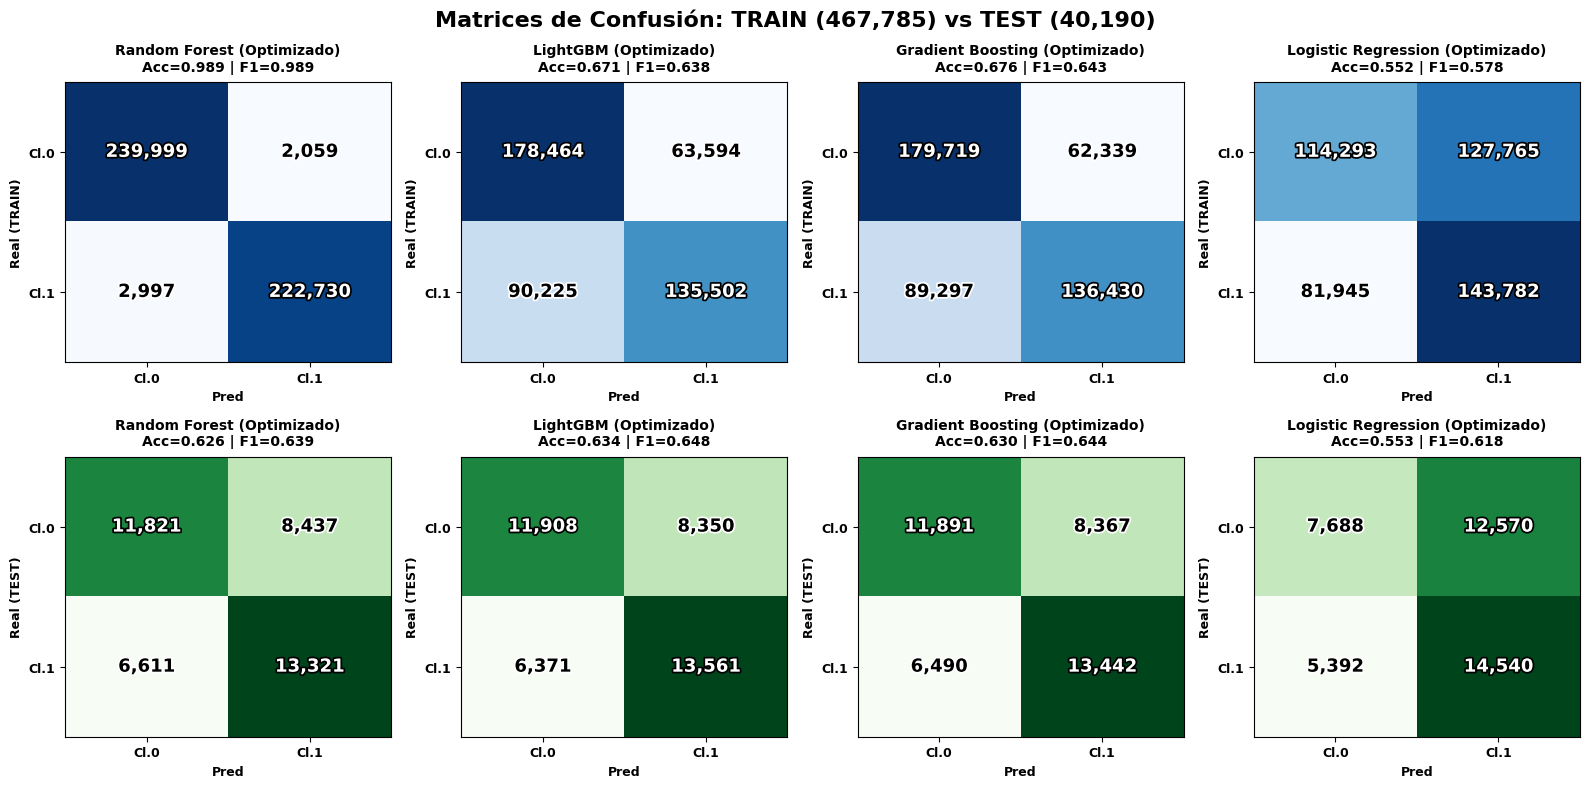


📊 MÉTRICAS MATRICES DE CONFUSIÓN - COMPARATIVA TRAIN vs TEST

                          Modelo  TRAIN_TN  TRAIN_FP  TRAIN_FN  TRAIN_TP TRAIN_Sens TRAIN_Spec  TEST_TN  TEST_FP  TEST_FN  TEST_TP TEST_Sens TEST_Spec
      Random Forest (Optimizado)    239999      2059      2997    222730      0.987      0.991    11821     8437     6611    13321     0.668     0.584
           LightGBM (Optimizado)    178464     63594     90225    135502      0.600      0.737    11908     8350     6371    13561     0.680     0.588
  Gradient Boosting (Optimizado)    179719     62339     89297    136430      0.604      0.742    11891     8367     6490    13442     0.674     0.587
Logistic Regression (Optimizado)    114293    127765     81945    143782      0.637      0.472     7688    12570     5392    14540     0.729     0.380

🔍 INTERPRETACIÓN DETALLADA - TRAIN vs TEST

🔹 RANDOM FOREST (OPTIMIZADO)
   ─────────────────────────────────────────────────────────────────────────────────────
   TRAIN (467,785 m

In [18]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as path_effects
from sklearn.metrics import confusion_matrix

print("\n" + "="*90)
print("🏆 MATRICES DE CONFUSIÓN - COMPARATIVA TRAIN vs TEST (4 MODELOS)")
print("="*90)

# Crear figura con subplots: 4 modelos x 2 particiones (TRAIN/TEST)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Matrices de Confusión: TRAIN (467,785) vs TEST (40,190)', 
             fontsize=16, fontweight='bold', y=0.98)

# Diccionarios para almacenar matrices
confusion_matrices_train = {}
confusion_matrices_test = {}
metrics_summary = []

# Función auxiliar para visualizar matriz
def plot_confusion_matrix(ax, cm, title, color='Blues'):
    """Graficar matriz de confusión en subplot con contraste mejorado."""
    im = ax.imshow(cm, cmap=color, aspect='auto')
    
    # Normalizar valores para evaluar brillo (0-1)
    max_val = cm.max()
    min_val = cm.min()
    
    for i in range(2):
        for j in range(2):
            value = cm[i, j]
            
            # Normalizar el valor (0-1) para evaluar brillo
            if max_val > min_val:
                normalized = (value - min_val) / (max_val - min_val)
            else:
                normalized = 0.5
            
            # Determinar color de texto basado en brillo percibido
            # Usar umbral más conservador (0.45) para mejor contraste
            if normalized > 0.45:
                text_color = "white"
                stroke_color = "black"
            else:
                text_color = "black"
                stroke_color = "white"
            
            # Texto con borde/trazo para mejor legibilidad
            text = ax.text(j, i, f"{value:,}", 
                          ha="center", va="center", 
                          color=text_color, 
                          fontsize=13, 
                          fontweight='bold')
            # Agregar efecto de borde usando patheffects
            text.set_path_effects([
                path_effects.Stroke(linewidth=2.5, foreground=stroke_color),
                path_effects.Normal()
            ])
    
    # Etiquetas de ejes
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Cl.0', 'Cl.1'], fontsize=9, fontweight='bold')
    ax.set_yticklabels(['Cl.0', 'Cl.1'], fontsize=9, fontweight='bold')
    ax.set_title(title, fontsize=10, fontweight='bold', pad=8)
    ax.set_ylabel('Real', fontsize=9, fontweight='bold')
    ax.set_xlabel('Pred', fontsize=9, fontweight='bold')

# Procesar cada modelo
for idx, result in enumerate(results_list):
    model_name = result['nombre']
    
    # ===== TRAIN =====
    y_train_true = result['train_actual'] if 'train_actual' in result else y_train
    y_train_pred = result['train_pred'] if 'train_pred' in result else result['model_obj'].predict(X_train)
    
    cm_train = confusion_matrix(y_train, y_train_pred)
    confusion_matrices_train[model_name] = cm_train
    tn_tr, fp_tr, fn_tr, tp_tr = cm_train.ravel()
    
    # ===== TEST =====
    y_test_true = result['y_test_actual']
    y_test_pred = result['y_pred_test']
    
    cm_test = confusion_matrix(y_test_true, y_test_pred)
    confusion_matrices_test[model_name] = cm_test
    tn_te, fp_te, fn_te, tp_te = cm_test.ravel()
    
    # Calcular métricas
    sensitivity_tr = tp_tr / (tp_tr + fn_tr) if (tp_tr + fn_tr) > 0 else 0
    specificity_tr = tn_tr / (tn_tr + fp_tr) if (tn_tr + fp_tr) > 0 else 0
    sensitivity_te = tp_te / (tp_te + fn_te) if (tp_te + fn_te) > 0 else 0
    specificity_te = tn_te / (tn_te + fp_te) if (tn_te + fp_te) > 0 else 0
    
    metrics_summary.append({
        'Modelo': model_name,
        'TRAIN_TN': int(tn_tr),
        'TRAIN_FP': int(fp_tr),
        'TRAIN_FN': int(fn_tr),
        'TRAIN_TP': int(tp_tr),
        'TRAIN_Sens': f"{sensitivity_tr:.3f}",
        'TRAIN_Spec': f"{specificity_tr:.3f}",
        'TEST_TN': int(tn_te),
        'TEST_FP': int(fp_te),
        'TEST_FN': int(fn_te),
        'TEST_TP': int(tp_te),
        'TEST_Sens': f"{sensitivity_te:.3f}",
        'TEST_Spec': f"{specificity_te:.3f}"
    })
    
    # Graficar TRAIN (fila 0)
    ax_train = axes[0, idx]
    train_acc = result['train']['accuracy']
    train_f1 = result['train']['f1']
    plot_confusion_matrix(ax_train, cm_train, 
                         f"{model_name}\nAcc={train_acc:.3f} | F1={train_f1:.3f}",
                         color='Blues')
    ax_train.set_ylabel('Real (TRAIN)', fontsize=9, fontweight='bold')
    
    # Graficar TEST (fila 1)
    ax_test = axes[1, idx]
    test_acc = result['test']['accuracy']
    test_f1 = result['test']['f1']
    plot_confusion_matrix(ax_test, cm_test, 
                         f"{model_name}\nAcc={test_acc:.3f} | F1={test_f1:.3f}",
                         color='Greens')
    ax_test.set_ylabel('Real (TEST)', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# Imprimir tabla comparativa
print("\n" + "="*90)
print("📊 MÉTRICAS MATRICES DE CONFUSIÓN - COMPARATIVA TRAIN vs TEST")
print("="*90)

df_metrics_full = pd.DataFrame(metrics_summary)
print("\n" + df_metrics_full.to_string(index=False))

# Análisis detallado
print("\n" + "="*90)
print("🔍 INTERPRETACIÓN DETALLADA - TRAIN vs TEST")
print("="*90)

for idx, result in enumerate(results_list):
    model_name = result['nombre']
    
    cm_tr = confusion_matrices_train[model_name]
    cm_te = confusion_matrices_test[model_name]
    
    tn_tr, fp_tr, fn_tr, tp_tr = cm_tr.ravel()
    tn_te, fp_te, fn_te, tp_te = cm_te.ravel()
    
    sens_tr = tp_tr / (tp_tr + fn_tr) if (tp_tr + fn_tr) > 0 else 0
    spec_tr = tn_tr / (tn_tr + fp_tr) if (tn_tr + fp_tr) > 0 else 0
    sens_te = tp_te / (tp_te + fn_te) if (tp_te + fn_te) > 0 else 0
    spec_te = tn_te / (tn_te + fp_te) if (tn_te + fp_te) > 0 else 0
    
    print(f"\n🔹 {model_name.upper()}")
    print(f"   {'─'*85}")
    print(f"   TRAIN ({len(X_train):,} muestras):")
    print(f"     TN={tn_tr:>6,} | FP={fp_tr:>6,} | FN={fn_tr:>6,} | TP={tp_tr:>6,}")
    print(f"     Sensibilidad (Clase 1): {sens_tr:6.1%} | Especificidad (Clase 0): {spec_tr:6.1%}")
    
    print(f"   TEST ({len(X_test):,} muestras):")
    print(f"     TN={tn_te:>6,} | FP={fp_te:>6,} | FN={fn_te:>6,} | TP={tp_te:>6,}")
    print(f"     Sensibilidad (Clase 1): {sens_te:6.1%} | Especificidad (Clase 0): {spec_te:6.1%}")
    
    # Detectar overfitting/underfitting
    sens_diff = sens_te - sens_tr
    spec_diff = spec_te - spec_tr
    
    print(f"   Cambio (TEST - TRAIN):")
    print(f"     ΔSensibilidad: {sens_diff:+.3f}  |  ΔEspecificidad: {spec_diff:+.3f}")
    
    if abs(sens_diff) < 0.03 and abs(spec_diff) < 0.03:
        print(f"   ✅ Estable (generaliza bien)")
    elif sens_diff < -0.05 or spec_diff < -0.05:
        print(f"   ⚠️  Posible overfitting (desempeño mejor en TRAIN que en TEST)")
    else:
        print(f"   📌 Comportamiento normal")

# Ganador
print(f"\n{'='*90}")
f1_scores = [r['test']['f1'] for r in results_list]
best_idx = np.argmax(f1_scores)
best_result = results_list[best_idx]

print(f"\n🏆 GANADOR GENERAL: {best_result['nombre']}")
print(f"   F1-Score (TEST): {best_result['test']['f1']:.4f}")
print(f"   Accuracy (TEST): {best_result['test']['accuracy']:.4f}")

cm_winner_te = confusion_matrices_test[best_result['nombre']]
tn, fp, fn, tp = cm_winner_te.ravel()
print(f"   Matriz TEST: TN={tn:,} | FP={fp:,} | FN={fn:,} | TP={tp:,}")

## 11.5 Predicciones en VAL (Out-of-Time) con Modelo Ganador

In [19]:
print(f"\n{'='*90}")
print(f"📊 Generando predicciones en VAL (Out-of-Time)")
print(f"   Modelo: {best_result['nombre']}")
print(f"   Reentrenado con: TRAIN + TEST + EXCLUIDO_TEST ({len(X_train_test_combined):,} muestras)")
print(f"   Umbral optimizado: {best_threshold:.2f}")
print(f"{'='*90}")

# Usar el modelo reentrenado (best_model_final) para hacer predicciones en VAL
y_pred_val_proba = best_model_final.predict_proba(X_val)[:, 1]

# IMPORTANTE: Aplicar umbral optimizado en lugar del umbral default de 0.5
y_pred_val = (y_pred_val_proba >= best_threshold).astype(int)

# Crear DataFrame con predicciones
df_predicciones_val = pd.DataFrame({
    'prediccion': y_pred_val,
    'probabilidad_positiva': y_pred_val_proba,
    'probabilidad_negativa': 1 - y_pred_val_proba
})

print(f"\n✅ Predicciones generadas: {len(df_predicciones_val)} registros")
print(f"   Umbral aplicado: {best_threshold:.2f}")

print(f"\n📊 Distribución de predicciones:")
print(df_predicciones_val['prediccion'].value_counts().sort_index())

print(f"\n📊 Estadísticas de probabilidades:")
print(f"  Media (clase positiva): {df_predicciones_val['probabilidad_positiva'].mean():.4f}")
print(f"  Min: {df_predicciones_val['probabilidad_positiva'].min():.4f}")
print(f"  Max: {df_predicciones_val['probabilidad_positiva'].max():.4f}")

print(f"\n📊 Estadísticas por clase (con umbral {best_threshold:.2f}):")
for pred_class in sorted(df_predicciones_val['prediccion'].unique()):
    mask = df_predicciones_val['prediccion'] == pred_class
    proba_mean = df_predicciones_val.loc[mask, 'probabilidad_positiva'].mean()
    count = mask.sum()
    print(f"  Clase {pred_class}: {count:,} predicciones (prob media: {proba_mean:.4f})")

print(f"\n🎯 Primeras 10 predicciones:")
print(df_predicciones_val.head(10).to_string(index=False))


📊 Generando predicciones en VAL (Out-of-Time)
   Modelo: LightGBM (Optimizado)
   Reentrenado con: TRAIN + TEST + EXCLUIDO_TEST (568,251 muestras)
   Umbral optimizado: 0.37

✅ Predicciones generadas: 112549 registros
   Umbral aplicado: 0.37

📊 Distribución de predicciones:
prediccion
0    33613
1    78936
Name: count, dtype: int64

📊 Estadísticas de probabilidades:
  Media (clase positiva): 0.4711
  Min: 0.0086
  Max: 0.9595

📊 Estadísticas por clase (con umbral 0.37):
  Clase 0: 33,613 predicciones (prob media: 0.2826)
  Clase 1: 78,936 predicciones (prob media: 0.5513)

🎯 Primeras 10 predicciones:
 prediccion  probabilidad_positiva  probabilidad_negativa
          1               0.453245               0.546755
          1               0.655343               0.344657
          1               0.487234               0.512766
          1               0.462235               0.537765
          0               0.292007               0.707993
          1               0.749437        

In [20]:
print("\n" + "="*90)
print("📊 ANÁLISIS DETALLADO DE PREDICCIONES EN VALIDACIÓN (Out-of-Time)")
print("="*90)

# Análisis de distribución de predicciones
print(f"\n🎯 DISTRIBUCIÓN DE PREDICCIONES (VAL - {len(df_predicciones_val):,} registros)")
print("-" * 90)

pred_counts = df_predicciones_val['prediccion'].value_counts().sort_index()
pred_0 = int(pred_counts.get(0.0, 0))
pred_1 = int(pred_counts.get(1.0, 0))
total = len(df_predicciones_val)

print(f"\n📌 Casos predichos como CLASE 0 (Negativo): {pred_0:>12,} ({pred_0/total*100:6.2f}%)")
print(f"📌 Casos predichos como CLASE 1 (Positivo): {pred_1:>12,} ({pred_1/total*100:6.2f}%)")
print(f"   {'─'*50}")
print(f"   TOTAL:                               {total:>12,} (100.00%)")

# Estadísticas de probabilidades
print(f"\n📈 ESTADÍSTICAS DE PROBABILIDADES PREDICHAS")
print("-" * 90)

prob_stats = df_predicciones_val['probabilidad_positiva'].describe()
print(f"\n  Métrica                  Valor")
print(f"  {'─'*45}")
print(f"  Cantidad                 {int(prob_stats['count']):,}")
print(f"  Media                    {prob_stats['mean']:.6f}")
print(f"  Desv. Estándar           {prob_stats['std']:.6f}")
print(f"  Mínimo                   {prob_stats['min']:.6f}")
print(f"  Cuartil 25%              {prob_stats['25%']:.6f}")
print(f"  Mediana (50%)            {prob_stats['50%']:.6f}")
print(f"  Cuartil 75%              {prob_stats['75%']:.6f}")
print(f"  Máximo                   {prob_stats['max']:.6f}")

# Distribución por rangos de probabilidad
print(f"\n📊 DISTRIBUCIÓN POR RANGOS DE PROBABILIDAD")
print("-" * 90)

prob_ranges = [
    (0.0, 0.1, "0.0  - 0.1"),
    (0.1, 0.2, "0.1  - 0.2"),
    (0.2, 0.3, "0.2  - 0.3"),
    (0.3, 0.4, "0.3  - 0.4"),
    (0.4, 0.5, "0.4  - 0.5"),
    (0.5, 0.6, "0.5  - 0.6"),
    (0.6, 0.7, "0.6  - 0.7"),
    (0.7, 0.8, "0.7  - 0.8"),
    (0.8, 0.9, "0.8  - 0.9"),
    (0.9, 1.0, "0.9  - 1.0"),
]

for low, high, label in prob_ranges:
    count = ((df_predicciones_val['probabilidad_positiva'] >= low) & 
             (df_predicciones_val['probabilidad_positiva'] < high)).sum()
    pct = count / total * 100
    bar_width = int(pct / 2)  # Escala visual
    bar = "█" * bar_width
    print(f"  [{label}]  {count:>8,}  ({pct:6.2f}%)  {bar}")

# Análisis de casos críticos
print(f"\n⚠️  CASOS CRÍTICOS (Probabilidades cercanas a 0.5)")
print("-" * 90)

critical_range = 0.05
critical_cases = df_predicciones_val[
    (df_predicciones_val['probabilidad_positiva'] >= 0.5 - critical_range) & 
    (df_predicciones_val['probabilidad_positiva'] <= 0.5 + critical_range)
]
critical_count = len(critical_cases)
critical_pct = critical_count / total * 100

print(f"\n  Rango crítico (0.45 - 0.55): {critical_count:,} casos ({critical_pct:.2f}%)")
print(f"  ⚠️  Estos son casos con predicción incierta (borde de decisión)")

# Comparación con distribución esperada
print(f"\n📋 COMPARACIÓN CON BASE ORIGINAL (TRAIN + TEST)")
print("-" * 90)

y_combined = pd.concat([y_train, y_test])
combined_0 = (y_combined == 0).sum()
combined_1 = (y_combined == 1).sum()
combined_total = len(y_combined)

print(f"\n  Clase          TRAIN+TEST          VAL Predichas         Diferencia")
print(f"  {'─'*75}")
print(f"  Clase 0        {combined_0:>8,} ({combined_0/combined_total*100:5.1f}%)  " +
      f"{pred_0:>8,} ({pred_0/total*100:5.1f}%)  " +
      f"{pred_0/total - combined_0/combined_total:+.2%}")
print(f"  Clase 1        {combined_1:>8,} ({combined_1/combined_total*100:5.1f}%)  " +
      f"{pred_1:>8,} ({pred_1/total*100:5.1f}%)  " +
      f"{pred_1/total - combined_1/combined_total:+.2%}")

# Top probabilidades predichas
print(f"\n🔝 TOP 10 PROBABILIDADES MÁS ALTAS (Mayor certeza positiva)")
print("-" * 90)
top_proba = df_predicciones_val.nlargest(10, 'probabilidad_positiva')[
    ['prediccion', 'probabilidad_positiva', 'probabilidad_negativa']
].reset_index(drop=True)
print(top_proba.to_string())

# Bottom probabilidades predichas
print(f"\n🔻 TOP 10 PROBABILIDADES MÁS BAJAS (Mayor certeza negativa)")
print("-" * 90)
bottom_proba = df_predicciones_val.nsmallest(10, 'probabilidad_positiva')[
    ['prediccion', 'probabilidad_positiva', 'probabilidad_negativa']
].reset_index(drop=True)
print(bottom_proba.to_string())

print("\n" + "="*90)
print(f"✅ ANÁLISIS COMPLETADO")
print("="*90)


📊 ANÁLISIS DETALLADO DE PREDICCIONES EN VALIDACIÓN (Out-of-Time)

🎯 DISTRIBUCIÓN DE PREDICCIONES (VAL - 112,549 registros)
------------------------------------------------------------------------------------------

📌 Casos predichos como CLASE 0 (Negativo):       33,613 ( 29.87%)
📌 Casos predichos como CLASE 1 (Positivo):       78,936 ( 70.13%)
   ──────────────────────────────────────────────────
   TOTAL:                                    112,549 (100.00%)

📈 ESTADÍSTICAS DE PROBABILIDADES PREDICHAS
------------------------------------------------------------------------------------------

  Métrica                  Valor
  ─────────────────────────────────────────────
  Cantidad                 112,549
  Media                    0.471074
  Desv. Estándar           0.171645
  Mínimo                   0.008627
  Cuartil 25%              0.352308
  Mediana (50%)            0.446897
  Cuartil 75%              0.593159
  Máximo                   0.959510

📊 DISTRIBUCIÓN POR RANGOS DE P

## 12. Feature Importance

In [21]:
print("\n" + "="*90)
print("📈 IMPORTANCIA DE FEATURES - COMPARATIVA DE MODELOS")
print("="*90)

# Diccionario para almacenar todas las importancias
feature_importance_dict = {}

# Random Forest
print("\n🌲 RANDOM FOREST")
print("-" * 90)
rf_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': result_rf['model_obj'].feature_importances_
}).sort_values('Importance', ascending=False)
feature_importance_dict['Random Forest'] = rf_importance.copy()
print(rf_importance.head(10).to_string(index=False))

# LightGBM
print("\n💡 LIGHTGBM")
print("-" * 90)
lgb_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': result_lgb['model_obj'].feature_importances_
}).sort_values('Importance', ascending=False)
feature_importance_dict['LightGBM'] = lgb_importance.copy()
print(lgb_importance.head(10).to_string(index=False))

# Gradient Boosting
print("\n🚀 GRADIENT BOOSTING CLASSIFIER")
print("-" * 90)
gbc_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': result_gbc['model_obj'].feature_importances_
}).sort_values('Importance', ascending=False)
feature_importance_dict['Gradient Boosting'] = gbc_importance.copy()
print(gbc_importance.head(10).to_string(index=False))

# Logistic Regression (coeficientes en lugar de importancia)
print("\n📊 LOGISTIC REGRESSION (Coeficientes)")
print("-" * 90)
lr_coef = pd.DataFrame({
    'Feature': X_train.columns,
    'Coeficiente': result_lr['model_obj'].coef_[0],
    'Abs_Coeficiente': np.abs(result_lr['model_obj'].coef_[0])
}).sort_values('Abs_Coeficiente', ascending=False)
feature_importance_dict['Logistic Regression'] = lr_coef.copy()
print(lr_coef[['Feature', 'Coeficiente', 'Abs_Coeficiente']].head(10).to_string(index=False))

print("\n⚠️  NOTA: SVM no tiene importancia de features disponible (modelo de kernel)")

# Resumen de Top 5 features por modelo
print("\n" + "="*90)
print("🏆 TOP 5 FEATURES POR MODELO")
print("="*90)

for model_name, imp_df in feature_importance_dict.items():
    print(f"\n{model_name}:")
    top_features = imp_df.head(5)
    for idx, row in top_features.iterrows():
        if model_name == 'Logistic Regression':
            print(f"  {row['Feature']}: {row['Coeficiente']:+.6f} (|coef|={row['Abs_Coeficiente']:.6f})")
        else:
            print(f"  {row['Feature']}: {row['Importance']:.6f}")


📈 IMPORTANCIA DE FEATURES - COMPARATIVA DE MODELOS

🌲 RANDOM FOREST
------------------------------------------------------------------------------------------
              Feature  Importance
      prob_propension    0.115920
       prob_auto_cura    0.102249
   prob_alrt_temprana    0.098028
valor_cuota_mes_pagos    0.058362
            total_ing    0.057713
          tot_activos    0.053462
       tot_patrimonio    0.053317
           pago_total    0.048261
          egresos_mes    0.044047
             edad_cli    0.041919

💡 LIGHTGBM
------------------------------------------------------------------------------------------
              Feature  Importance
      prob_propension        1229
       prob_auto_cura        1093
   prob_alrt_temprana        1033
            total_ing        1016
            porc_pago         957
          egresos_mes         867
valor_cuota_mes_pagos         851
          tot_activos         810
       tot_patrimonio         779
       producto_pagos  

## 13. Guardar Resultados

In [22]:
# Crear directorio de salida
output_dir = base_path / 'outputs' / datetime.now().strftime('%Y%m%d_%H%M%S')
output_dir.mkdir(parents=True, exist_ok=True)

print(f"\n{'='*70}")
print(f"📁 GUARDANDO ARTEFACTOS")
print(f"{'='*70}")
print(f"\n📂 Directorio: {output_dir}\n")

# Guardar modelos individuales del torneo (para referencia)
print("🤖 Modelos (Torneo - solo referencia):")
for res in results_list:
    model_name = res['nombre'].lower().replace(' ', '_')
    model_path = output_dir / f"{model_name}_model.pkl"
    with open(model_path, 'wb') as f:
        pickle.dump(res['model_obj'], f)
    print(f"  ✓ {model_name}_model.pkl")

# Guardar modelo GANADOR FINAL (reentrenado con TRAIN + TEST + EXCLUIDO_TEST)
print("\n🏆 Modelo Ganador Final (Reentrenado):")
best_model_final_path = output_dir / 'modelo_ganador_final.pkl'
with open(best_model_final_path, 'wb') as f:
    pickle.dump(best_model_final, f)
print(f"  ✓ modelo_ganador_final.pkl ({best_result['nombre']})")
print(f"    Entrenado con: {len(X_train_test_combined):,} muestras (TRAIN + TEST + EXCLUIDO_TEST)")
print(f"      - TRAIN:         {len(X_train):,}")
print(f"      - TEST:          {len(X_test):,}")
print(f"      - EXCLUIDO_TEST: {len(X_excluido_test):,}")



📁 GUARDANDO ARTEFACTOS

📂 Directorio: c:\Users\seaherre\Documents\Repositorios\prueba-tecnica\src\torneo_modelos\outputs\20260913_124601

🤖 Modelos (Torneo - solo referencia):
  ✓ random_forest_(optimizado)_model.pkl
  ✓ lightgbm_(optimizado)_model.pkl
  ✓ gradient_boosting_(optimizado)_model.pkl
  ✓ logistic_regression_(optimizado)_model.pkl

🏆 Modelo Ganador Final (Reentrenado):
  ✓ modelo_ganador_final.pkl (LightGBM (Optimizado))
    Entrenado con: 568,251 muestras (TRAIN + TEST + EXCLUIDO_TEST)
      - TRAIN:         467,785
      - TEST:          40,190
      - EXCLUIDO_TEST: 60,276


In [23]:
# Guardar resultados JSON (solo TRAIN y TEST del torneo)
print("\n📊 Resultados de evaluación (Torneo):")
results_json = []
for r in results_list:
    r_json = {
        'modelo': r['nombre'],
        'train': {k: float(v) for k, v in r['train'].items()},
        'test': {k: float(v) for k, v in r['test'].items()}
    }
    results_json.append(r_json)

# Agregar información del umbral óptimo y reentrenamiento
retraining_info = {
    'tipo': 'reentrenamiento_y_threshold_optimization',
    'modelo_ganador': best_result['nombre'],
    'datos_entrenamiento': {
        'TRAIN': int(len(X_train)),
        'TEST': int(len(X_test)),
        'EXCLUIDO_TEST': int(len(X_excluido_test)),
        'Total_Combinado': int(len(X_train_test_combined))
    },
    'threshold_optimization': {
        'umbral_optimo': round(float(best_threshold), 4),
        'f1_score_optimo': round(float(best_f1), 4),
        'datos_referencia': 'TEST + EXCLUIDO_TEST',
        'metrica_optimizada': 'F1-Score'
    },
    'metricas_modelo_final': {
        'accuracy': round(float(combined_acc), 4),
        'precision': round(float(combined_precision), 4),
        'recall': round(float(combined_recall), 4),
        'f1_score': round(float(combined_f1), 4),
        'auc_roc': round(float(combined_auc), 4)
    }
}
results_json.append(retraining_info)

json_path = output_dir / 'resultados.json'
with open(json_path, 'w') as f:
    json.dump(results_json, f, indent=2)
print(f"  ✓ resultados.json")
print(f"    - Incluye: Métricas torneo + Umbral optimizado + Info reentrenamiento")

# Guardar umbral óptimo en archivo separado para fácil acceso
threshold_config = {
    'umbral_optimo': round(float(best_threshold), 4),
    'f1_score_en_test_excluido': round(float(best_f1), 4),
    'modelo': best_result['nombre'],
    'notas': 'Este umbral fue optimizado en TEST + EXCLUIDO_TEST y debe aplicarse en predicciones de VAL'
}
threshold_path = output_dir / 'optimal_threshold.json'
with open(threshold_path, 'w') as f:
    json.dump(threshold_config, f, indent=2)
print(f"  ✓ optimal_threshold.json")
print(f"    Umbral óptimo: {best_threshold:.4f}")

# Guardar predicciones del modelo ganador FINAL (reentrenado)
print("\n📊 Predicciones del modelo ganador FINAL:")

# Generar predicciones en TRAIN (del modelo reentrenado)
y_train_pred_final = best_model_final.predict(X_train)
y_train_proba_final = best_model_final.predict_proba(X_train)[:, 1]
df_train_pred = pd.DataFrame({
    'prediccion': y_train_pred_final,
    'probabilidad_positiva': y_train_proba_final,
    'probabilidad_negativa': 1 - y_train_proba_final,
    'real': y_train.values
})
df_train_pred.to_csv(output_dir / 'predicciones_train.csv', index=False)
print(f"  ✓ predicciones_train.csv ({len(df_train_pred):,} registros)")
print(f"    (Del modelo reentrenado con TRAIN+TEST+EXCLUIDO_TEST)")

# Generar predicciones en TEST (del modelo reentrenado)
y_test_pred_final = best_model_final.predict(X_test)
y_test_proba_final = best_model_final.predict_proba(X_test)[:, 1]
df_test_pred = pd.DataFrame({
    'prediccion': y_test_pred_final,
    'probabilidad_positiva': y_test_proba_final,
    'probabilidad_negativa': 1 - y_test_proba_final,
    'real': y_test.values
})
df_test_pred.to_csv(output_dir / 'predicciones_test.csv', index=False)
print(f"  ✓ predicciones_test.csv ({len(df_test_pred):,} registros)")
print(f"    (Del modelo reentrenado con TRAIN+TEST+EXCLUIDO_TEST)")

# Guardar predicciones VAL (FINAL - con modelo reentrenado)
print("\n📊 Predicciones VAL (Modelo Ganador FINAL - Reentrenado):")

# Obtener datos originales para el conjunto VAL
df_val_original = df[val_idx].copy()

# Crear ID concatenando: nit_enmascarado#num_oblig_orig_enmascarado#num_oblig_enmascarado
print(f"  - Generando IDs concatenados...")
df_val_original['ID'] = (
    df_val_original['nit_enmascarado'].astype(str) + '#' +
    df_val_original['num_oblig_orig_enmascarado'].astype(str) + '#' +
    df_val_original['num_oblig_enmascarado'].astype(str)
)

# Crear DataFrame final con las columnas requeridas
df_predicciones_val_final = pd.DataFrame({
    'ID': df_val_original['ID'].values,
    'var_rpta_alt': y_pred_val.astype(int),
})

# Guardar como CSV con encoding UTF-8 y delimitador coma
csv_val_path = output_dir / 'resultado_prueba.csv'
df_predicciones_val_final.to_csv(
    csv_val_path, 
    index=False, 
    encoding='utf-8', 
    sep=','
)
print(f"  ✓ resultado_prueba.csv ({len(df_predicciones_val_final):,} registros)")
print(f"    Encoding: UTF-8 | Delimitador: coma")
print(f"    Columnas: ID | var_rpta_alt (entero)")
print(f"    ⚠️  Predicciones generadas con umbral optimizado: {best_threshold:.4f}")


📊 Resultados de evaluación (Torneo):
  ✓ resultados.json
    - Incluye: Métricas torneo + Umbral optimizado + Info reentrenamiento
  ✓ optimal_threshold.json
    Umbral óptimo: 0.3700

📊 Predicciones del modelo ganador FINAL:
  ✓ predicciones_train.csv (467,785 registros)
    (Del modelo reentrenado con TRAIN+TEST+EXCLUIDO_TEST)
  ✓ predicciones_test.csv (40,190 registros)
    (Del modelo reentrenado con TRAIN+TEST+EXCLUIDO_TEST)

📊 Predicciones VAL (Modelo Ganador FINAL - Reentrenado):
  - Generando IDs concatenados...
  ✓ resultado_prueba.csv (112,549 registros)
    Encoding: UTF-8 | Delimitador: coma
    Columnas: ID | var_rpta_alt (entero)
    ⚠️  Predicciones generadas con umbral optimizado: 0.3700


## 14. Resumen Final

In [24]:
print("\n" + "="*70)
print("✅ TORNEO Y REENTRENAMIENTO COMPLETADOS EXITOSAMENTE")
print("="*70)
print(f"\n📊 RESUMEN DEL TORNEO (TRAIN vs TEST):")
print(f"  Modelos evaluados: {len(results_list)}")
print(f"  Modelo ganador: {best_result['nombre']}")
print(f"  F1-Score (TEST): {best_result['test']['f1']:.4f}")
print(f"  Accuracy (TEST): {best_result['test']['accuracy']:.4f}")

print(f"\n🏆 MODELO FINAL (REENTRENADO CON TRAIN + TEST + EXCLUIDO_TEST):")
print(f"  Modelo: {best_result['nombre']}")
print(f"  Muestras de entrenamiento: {len(X_train_test_combined):,}")
print(f"  Desempeño combinado:")
print(f"    - Accuracy: {combined_acc:.4f}")
print(f"    - F1-Score: {combined_f1:.4f}")
print(f"    - AUC-ROC:  {combined_auc:.4f}")

print(f"\n📈 PARTICIONES DE DATOS:")
print(f"  TRAIN (original):              {len(X_train):,} muestras")
print(f"  TEST:                          {len(X_test):,} muestras")
print(f"  EXCLUIDO_TEST:                 {len(X_excluido_test):,} muestras")
print(f"  TRAIN + TEST + EXCLUIDO_TEST:  {len(X_train_test_combined):,} muestras (modelo final)")
print(f"  VAL (predicciones):            {len(X_val):,} muestras")
print(f"  {'─'*60}")
print(f"  TOTAL:                         {len(X_train) + len(X_test) + len(X_excluido_test) + len(X_val):,} muestras")

print(f"\n🎯 PERFORMANCE COMPARATIVA (Torneo - TRAIN vs TEST):")
for r in results_list:
    print(f"  {r['nombre']:40s}: F1={r['test']['f1']:.4f}, AUC={r['test']['auc']:.4f}")

print(f"\n🔮 PREDICCIONES VAL (Out-of-Time):")
print(f"  Modelo utilizado: {best_result['nombre']} (Reentrenado con TRAIN+TEST+EXCLUIDO_TEST)")
print(f"  Registros predichos: {len(df_predicciones_val):,}")
print(f"  Archivo salida: resultado_prueba.csv")

print(f"\n📁 ARTEFACTOS GUARDADOS EN: {output_dir}")
print("="*70)



✅ TORNEO Y REENTRENAMIENTO COMPLETADOS EXITOSAMENTE

📊 RESUMEN DEL TORNEO (TRAIN vs TEST):
  Modelos evaluados: 4
  Modelo ganador: LightGBM (Optimizado)
  F1-Score (TEST): 0.6482
  Accuracy (TEST): 0.6337

🏆 MODELO FINAL (REENTRENADO CON TRAIN + TEST + EXCLUIDO_TEST):
  Modelo: LightGBM (Optimizado)
  Muestras de entrenamiento: 568,251
  Desempeño combinado:
    - Accuracy: 0.6656
    - F1-Score: 0.6256
    - AUC-ROC:  0.7298

📈 PARTICIONES DE DATOS:
  TRAIN (original):              467,785 muestras
  TEST:                          40,190 muestras
  EXCLUIDO_TEST:                 60,276 muestras
  TRAIN + TEST + EXCLUIDO_TEST:  568,251 muestras (modelo final)
  VAL (predicciones):            112,549 muestras
  ────────────────────────────────────────────────────────────
  TOTAL:                         680,800 muestras

🎯 PERFORMANCE COMPARATIVA (Torneo - TRAIN vs TEST):
  Random Forest (Optimizado)              : F1=0.6391, AUC=0.6775
  LightGBM (Optimizado)                   : F1=0